In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)
np.set_printoptions(precision=3, suppress=True)

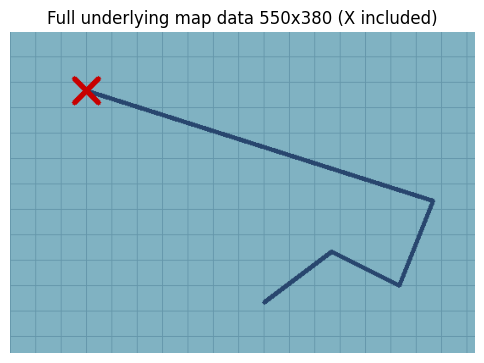

In [2]:
def make_treasure_map(w=550, h=380):
    img = np.full((h, w, 3), (194, 178, 128), dtype=np.uint8)
    for x in range(0, w, 30):
        cv2.line(img, (x, 0), (x, h), (170, 150, 100), 1)
    for y in range(0, h, 30):
        cv2.line(img, (0, y), (w, y), (170, 150, 100), 1)
    pts = np.array([[300, h - 60], [380, h - 120], [460, h - 80], [500, 200], [90, 70]])
    cv2.polylines(img, [pts], False, (110, 70, 40), 3)
    x_center = (90, 70)
    s = 14
    cv2.line(img, (x_center[0]-s, x_center[1]-s), (x_center[0]+s, x_center[1]+s), (0, 0, 200), 5)
    cv2.line(img, (x_center[0]-s, x_center[1]+s), (x_center[0]+s, x_center[1]-s), (0, 0, 200), 5)
    return img

map_img = make_treasure_map()
cv2.imwrite('data_map.png', map_img)
plt.figure(figsize=(6, 4.5))
plt.imshow(cv2.cvtColor(map_img, cv2.COLOR_BGR2RGB))
plt.title(f'Full underlying map data {map_img.shape[1]}x{map_img.shape[0]} (X included)')
plt.axis('off')
plt.savefig('output/00_full_map_data.png', bbox_inches='tight', dpi=150)
plt.show()

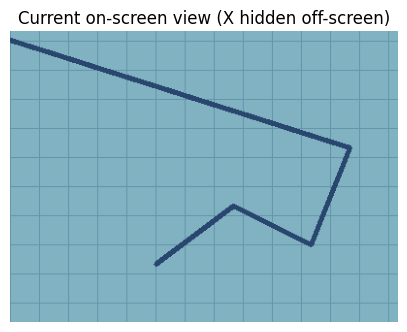

In [3]:
view_w, view_h = 400, 300
M_bug = np.array([[1.0, 0.0, -150.0], [0.0, 1.0, -80.0]])

broken_view = cv2.warpAffine(map_img, M_bug, (view_w, view_h), borderValue=(194, 178, 128))

plt.figure(figsize=(5, 4))
plt.imshow(cv2.cvtColor(broken_view, cv2.COLOR_BGR2RGB))
plt.title('Current on-screen view (X hidden off-screen)')
plt.axis('off')
plt.savefig('output/01_broken_view.png', bbox_inches='tight', dpi=150)
plt.show()

Translation correction matrix T =
 [[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]
Composed matrix T @ M_bug (should be identity) =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


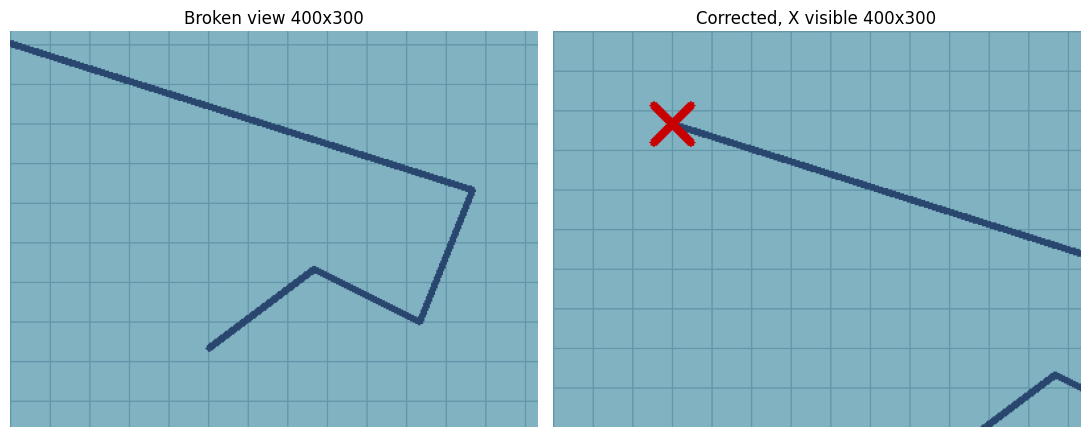

In [4]:
tx, ty = 150, 80
T_fix = np.array([
    [1.0, 0.0, tx],
    [0.0, 1.0, ty],
    [0.0, 0.0, 1.0]
])
print('Translation correction matrix T =\n', T_fix)

M_bug_h = np.vstack([M_bug, [0.0, 0.0, 1.0]])
M_corrected = T_fix @ M_bug_h
print('Composed matrix T @ M_bug (should be identity) =\n', M_corrected)

fixed_view = cv2.warpAffine(map_img, M_corrected[:2, :], (view_w, view_h), borderValue=(194, 178, 128))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(cv2.cvtColor(broken_view, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Broken view {view_w}x{view_h}')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(fixed_view, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Corrected, X visible {view_w}x{view_h}')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/02_fixed_view.png', bbox_inches='tight', dpi=150)
plt.show()